In [1]:
import numpy as np
import pandas as pd 

In [2]:
df=pd.read_csv('candy-data.csv')

In [3]:
df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [4]:
print(df.isnull().sum())

competitorname      0
chocolate           0
fruity              0
caramel             0
peanutyalmondy      0
nougat              0
crispedricewafer    0
hard                0
bar                 0
pluribus            0
sugarpercent        0
pricepercent        0
winpercent          0
dtype: int64


In [5]:
df.describe()

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,0.435294,0.447059,0.164706,0.164706,0.082353,0.082353,0.176471,0.247059,0.517647,0.478647,0.468882,50.316764
std,0.498738,0.500140,0.373116,0.373116,0.276533,0.276533,0.383482,0.433861,0.502654,0.282778,0.285740,14.714357
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.011000,0.011000,22.445341
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.220000,0.255000,39.141056
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.465000,0.465000,47.829754
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.732000,0.651000,59.863998
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.988000,0.976000,84.180290


In [7]:
df.shape

(85, 13)

In [8]:
df = df.drop(columns='competitorname' , axis=1)

In [11]:
numeric = df.select_dtypes(include=['fruity','caramel'  , 'peanutyalmondy' , 'nougat' ,'crispedricewafer' , 'hard' ,'bar'  ,'pluribus' , 'sugarpercent' ,'pricepercent' , 'winpercent'])


TypeError: data type 'fruity' not understood

In [14]:
x = df[['fruity','caramel' , 'peanutyalmondy' , 'nougat' ,'crispedricewafer' , 'hard' ,'bar'  ,'pluribus' , 'sugarpercent' ,'pricepercent' , 'winpercent' ]]
y = df[['chocolate']]


In [16]:
from sklearn.model_selection import train_test_split
trainingset , testset = train_test_split(df , test_size=0.2)

In [17]:
train_df = trainingset
test_df = testset

In [18]:
x_train=train_df[['fruity','caramel' , 'peanutyalmondy' , 'nougat' ,'crispedricewafer' , 'hard' ,'bar'  ,'pluribus' , 'sugarpercent' ,'pricepercent' , 'winpercent' ]]
y_train = train_df[['chocolate']]
x_test = test_df[['fruity','caramel' , 'peanutyalmondy' , 'nougat' ,'crispedricewafer' , 'hard' ,'bar'  ,'pluribus' , 'sugarpercent' ,'pricepercent' , 'winpercent' ]]
y_test=test_df[['chocolate']]

In [19]:
y_train.value_counts()

chocolate
0            38
1            30
Name: count, dtype: int64

In [20]:
import seaborn as sns

In [24]:
import matplotlib.pyplot as plt

C:\Users\HP\AppData\Local\Temp\ipykernel_17396\1384227140.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="chocolate" , data=train_df  , palette='Blues_d' ,legend=False)


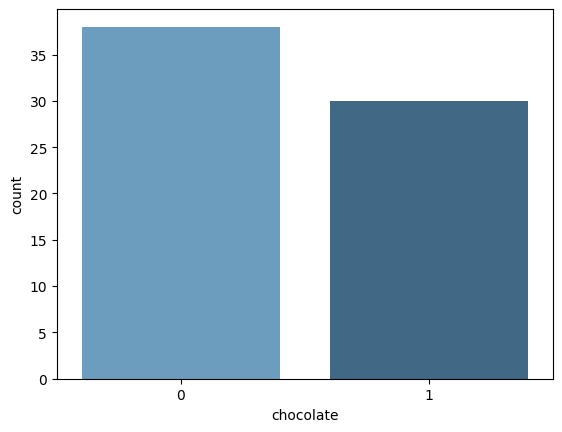

<Figure size 640x480 with 0 Axes>

In [34]:
sns.countplot(x="chocolate" , data=train_df  , palette='Blues_d' ,legend=False)
plt.show()
plt.savefig('count_plot')


In [36]:
count_no_choc = len (train_df[train_df['chocolate' ]==0])
count_choc = len(train_df[train_df['chocolate' ]==1])
pct_of_no_choc = count_no_choc /(count_no_choc +count_choc)
print ("percentage of no chocolate is", pct_of_no_choc*100) 
pct_of_choc = count_choc/(count_no_choc+count_choc)
print ("percentage of chocolate", pct_of_choc*100)

percentage of no chocolate is 55.88235294117647
percentage of chocolate 44.11764705882353


In [37]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
y_pred = logreg.predict(x_test)

c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [39]:
from sklearn import metrics

cnf_matrix = metrics.confusion_matrix(y_test , y_pred)
print(cnf_matrix)

[[10  0]
 [ 1  6]]
